# Analyse a WRF-Hydro / CTSM coupled run

This notebook reads the output of the case built and run by `build.ipynb` and walks
through what the coupled system produced. It is written to be read top to bottom the
first time: every section says what the files are, what the variables mean, and what
you should expect to see, before it plots anything.

## What ran

Three model components, coupled through the CESM mediator (CMEPS) using ESMF/NUOPC:

```
   NLDAS-2 forcing files            CTSM                          WRF-Hydro
   ──────────────────            ──────────────                ───────────────────
        DATM        ──(atm→lnd)──►  land surface   ──(lnd→rof)──►  terrain + channel
   0.125° CONUS grid            0.125° CONUS grid   ◄─(rof→lnd)──   routing
   464 × 224 cells               464 × 224 cells                  1 km LSM grid  319 × 234
                                                                  250 m routing grid (AGGFACTRT=4)
                                                                  N. Utah / S. Idaho
                    └──────────── mediator (CMEPS) remaps between grids ────────────┘
```

| Component | Role | Grid |
|---|---|---|
| **DATM** | *Data atmosphere.* Not a model — it reads NLDAS-2 reanalysis (radiation, precipitation, T/q/wind/pressure) from disk and hands it to the land. | 0.125° lat/lon, CONUS |
| **CTSM** | *Community Terrestrial Systems Model*, the CESM land model. Energy balance, snow, soil temperature and moisture, runoff generation. Configured here as `CLM50%NWP-SP` — satellite phenology, no biogeochemistry, 4 soil layers to 2 m to match WRF-Hydro. | 0.125° lat/lon, CONUS |
| **WRF-Hydro** | Hydrologic routing: overland flow, subsurface lateral flow, groundwater buckets, channel network, lakes. It receives soil state and runoff from CTSM and returns channel water back. In CESM terms it is the **ROF** (river runoff) component. | 1 km Lambert conformal over northern Utah; routing on a 4× finer grid |
| **CMEPS** | The mediator. Owns the run sequence, regrids fields between component grids, accumulates fluxes. | — |

The exchange between CTSM and WRF-Hydro is the new part of this project. Those fields
are the focus of sections 5–7.

**Run length:** 1 simulated hour, 2000-01-01 00:00 → 01:00 UTC. That is short enough
that the interesting content is *whether the plumbing works*, not the hydrology. The
notebook is written so that a longer run drops in with no changes.

## What you need

The `npl` kernel on NCAR JupyterHub has everything: `xarray`, `netCDF4`, `matplotlib`,
`numpy`, `pandas`. No modules need loading — this notebook only reads files.

## 1. Locate the run

Mirrors `build.ipynb`: the machine comes from `LMOD_SYSTEM_NAME`, the case name follows
from it. Three directories matter:

| | Contains |
|---|---|
| **case dir** `$SCRATCH/cases/<case>` | the CIME case: `env_*.xml`, namelists, `timing/` |
| **run dir** `$SCRATCH/<case>/run` | where the model executed: WRF-Hydro output, restart files, `DOMAIN/`, `ESMF_Profile.summary` |
| **archive** `$SCRATCH/archive/<case>` | `case.st_archive` moves logs and history here after the run; the run dir keeps only what the next run needs |

In [1]:
import os, re, sys, glob, gzip, warnings
from pathlib import Path

# The npl environment's GDAL does not find its PROJ database on its own; without this
# the first open_dataset() prints "ERROR 1: PROJ: proj_create_from_database ..." once.
# Harmless, but it looks alarming, and the fix is one line.
os.environ.setdefault("PROJ_DATA", str(Path(sys.prefix) / "share" / "proj"))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm

warnings.filterwarnings("ignore", category=xr.SerializationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "font.size": 9})

MACHINE   = os.environ.get("LMOD_SYSTEM_NAME") or os.environ.get("NCAR_HOST") or "derecho"
CASE_NAME = f"hydro-test-{MACHINE}"          # override here to look at a different case

SCRATCH  = Path(os.environ.get("SCRATCH") or f"/glade/derecho/scratch/{os.environ.get('USER', '')}")
CASE_DIR = SCRATCH / "cases" / CASE_NAME
RUN_DIR  = SCRATCH / CASE_NAME / "run"
ARCHIVE  = SCRATCH / "archive" / CASE_NAME

for name, p in [("case", CASE_DIR), ("run", RUN_DIR), ("archive", ARCHIVE)]:
    print(f"{name:8s} {p}   {'ok' if p.is_dir() else 'MISSING'}")
assert RUN_DIR.is_dir(), "no run directory -- has the case been run?"

case     /glade/derecho/scratch/soren/cases/hydro-test-casper   ok
run      /glade/derecho/scratch/soren/hydro-test-casper/run   ok
archive  /glade/derecho/scratch/soren/archive/hydro-test-casper   ok


### 1.1 What is in the run directory

WRF-Hydro names its output `<YYYYMMDDHHMM>.<TYPE>_DOMAIN1`; one file per output time per
type. CESM components name theirs `<case>.<comp>.<kind>.<date>.nc`. Everything else is
input or configuration.

In [2]:
def inventory(run_dir):
    rows = []
    for p in sorted(run_dir.iterdir()):
        if p.is_dir():
            kind = "directory"
        elif p.is_symlink():
            kind = "link -> " + os.readlink(p)
        elif re.match(r"\d{12}\.\w+_DOMAIN1$", p.name) or re.match(r"\d{12}\.\w+_GRID1$", p.name):
            kind = "WRF-Hydro output"
        elif ".clm2.r." in p.name or ".cpl.r." in p.name or ".datm.r." in p.name:
            kind = "restart"
        elif ".clm2.rh" in p.name:
            kind = "restart-history"
        elif ".clm2.h" in p.name:
            kind = "CTSM history"
        elif p.name.startswith("rpointer"):
            kind = "restart pointer"
        else:
            kind = "config / other"
        size = p.stat().st_size if not p.is_dir() else sum(f.stat().st_size for f in p.rglob("*") if f.is_file())
        rows.append((p.name, kind, size / 1e6))
    return pd.DataFrame(rows, columns=["file", "kind", "MB"])

inv = inventory(RUN_DIR)
with pd.option_context("display.max_rows", 200, "display.width", 140):
    display(inv)
print("\nby kind:")
print(inv.groupby("kind")["MB"].agg(["count", "sum"]).round(1))

,file,kind,MB
0,200001010000.CHRTOUT_DOMAIN1,WRF-Hydro output,1.605351
1,200001010000.CHRTOUT_GRID1,WRF-Hydro output,9.613215
2,200001010000.GWOUT_DOMAIN1,WRF-Hydro output,0.308134
3,200001010000.LAKEOUT_DOMAIN1,WRF-Hydro output,0.036789
4,200001010000.LSMOUT_DOMAIN1,WRF-Hydro output,4.255330
5,200001010100.CHRTOUT_DOMAIN1,WRF-Hydro output,1.605351
6,200001010100.CHRTOUT_GRID1,WRF-Hydro output,9.613215
7,200001010100.GWOUT_DOMAIN1,WRF-Hydro output,0.308134
8,200001010100.LAKEOUT_DOMAIN1,WRF-Hydro output,0.036789
9,200001010100.LSMOUT_DOMAIN1,WRF-Hydro output,4.255330



by kind:
                                                    count     sum
kind                                                             
WRF-Hydro output                                       10    31.6
config / other                                         13    31.7
directory                                               4  1146.6
link -> /glade/derecho/scratch/soren/cases/hydr...      1     0.0
link -> /glade/derecho/scratch/soren/cases/hydr...      1     0.0
restart                                                 3   561.3
restart pointer                                         4     0.0
restart-history                                         2   463.8


Two things to notice before going on.

**There is no `*.clm2.h0.*` file.** CTSM writes history (its normal diagnostic output)
monthly by default, and the run is one hour long, so nothing was written. The land
state in this notebook therefore comes from the *restart* file, which holds the full
model state at the final instant. To get proper hourly CTSM history next time, put this
in `user_nl_clm` in the case directory before `case.build`:

```
hist_nhtfrq = -1      ! history every 1 hour (negative = hours, positive = timesteps, 0 = monthly)
hist_mfilt  = 24      ! 24 samples per file
```

**WRF-Hydro wrote two output times, `00:00` and `01:00`.** The `t0OutputFlag = 1`
setting in `hydro.namelist` writes the initial state as well, which is useful: the
`00:00` files show what WRF-Hydro started with, *before* anything arrived from CTSM.

## 2. How the run was configured

Before looking at output it is worth knowing what the driver did. Four files say it all.

- **`nuopc.runseq`** — the run sequence: the order components are called and the
  coupling interval. This case ships a custom one from the case root.
- **`nuopc.runconfig`** — everything the mediator was told: coupling intervals per
  component, start/stop, mesh files.
- **`hydro.namelist`** — WRF-Hydro's own configuration: which routing schemes are on,
  grids, timesteps, what to output.
- **`lnd_in`** — CTSM's namelist: surface dataset, initial conditions.

In [3]:
print((RUN_DIR / "nuopc.runseq").read_text())

runSeq::
@30
  ATM
  ATM -> MED :remapMethod=redist
  MED med_phases_post_atm

  MED med_phases_prep_lnd
  MED -> LND :remapMethod=redist
  LND
  LND -> MED :remapMethod=redist
  MED med_phases_post_lnd

  MED med_phases_prep_rof
  MED -> ROF :remapMethod=redist
  ROF
  ROF -> MED :remapMethod=redist
  MED med_phases_post_rof

  MED med_phases_history_write
  MED med_phases_restart_write
  MED med_phases_profile
@
::



Read `@30` as "repeat this block every 30 seconds". Inside it, each component runs
once and the mediator remaps its output to whoever consumes it. So ATM, LND and ROF are
all called every 30 s — 120 times in the hour.

That is unusual. `nuopc.runconfig` below records the per-component intervals CIME
*thinks* it set (`ATM_NCPL`/`LND_NCPL` = 48/day → 1800 s; `ROF_NCPL` = 24/day → 3600 s),
but a custom `nuopc.runseq` overrides them. The 30 s loop is why the land model, which
normally steps every 30 min, is the most expensive component here (section 3).

In [4]:
runconfig = (RUN_DIR / "nuopc.runconfig").read_text()
keys = ["component_list", "atm_cpl_dt", "lnd_cpl_dt", "rof_cpl_dt", "start_ymd", "start_tod",
        "stop_option", "stop_n", "mesh_atm", "mesh_lnd", "mesh_rof", "coupling_mode", "flds_r2l_stream_channel_depths"]
rows = []
for k in keys:
    m = re.search(rf"^\s*{k}\s*[:=]\s*(.+?)\s*$", runconfig, re.M)
    rows.append((k, m.group(1) if m else "-"))
display(pd.DataFrame(rows, columns=["nuopc.runconfig", "value"]).style.hide(axis="index"))

nuopc.runconfig,value
component_list,MED ATM LND ROF
atm_cpl_dt,1800
lnd_cpl_dt,1800
rof_cpl_dt,3600
start_ymd,20000101
start_tod,0
stop_option,nhours
stop_n,1
mesh_atm,/glade/campaign/cesm/cesmdata/inputdata/share/meshes/0.125nldas2_ESMFmesh_cd5_241220.nc
mesh_lnd,/glade/campaign/cesm/cesmdata/inputdata/share/meshes/0.125nldas2_ESMFmesh_cd5_241220.nc


### 2.1 WRF-Hydro's namelist

Only the switches that decide what happens are shown. The ones that matter most:

| Setting | Meaning |
|---|---|
| `sys_cpl = 4` | WRF-Hydro's coupling mode. 4 is the CESM/NUOPC cap. |
| `DXRT`, `AGGFACTRT` | Routing grid spacing and its refinement relative to the 1 km LSM grid. `250 m` and `4` mean the routing grid should be 4× finer in each direction than the LSM grid. |
| `SUBRTSWCRT`, `OVRTSWCRT` | Subsurface and overland routing on the fine grid. |
| `CHANRTSWCRT`, `channel_option = 3` | Channel routing on; option 3 is gridded diffusive wave (the channel is a set of fine-grid cells, not a vector network). |
| `GWBASESWCRT = 1` | Groundwater buckets: each basin has a conceptual bucket that receives drainage and leaks to the channel. |
| `lake_option = 1` | Level-pool lakes. |
| `DTRT_TER`, `DTRT_CH` | Terrain and channel routing timesteps (seconds). |
| `NSOIL`, `ZSOIL8` | Number of soil layers and their bottom depths. These must match what CTSM sends. |
| `out_dt = 60` | Output every 60 minutes. |

In [5]:
hydro_nml = (RUN_DIR / "hydro.namelist").read_text()
show = ["sys_cpl", "GEO_STATIC_FLNM", "GEO_FINEGRID_FLNM", "DXRT", "AGGFACTRT", "DTRT_TER", "DTRT_CH",
        "SUBRTSWCRT", "OVRTSWCRT", "rt_option", "CHANRTSWCRT", "channel_option", "lake_option",
        "GWBASESWCRT", "NSOIL", "ZSOIL8(1)", "ZSOIL8(2)", "ZSOIL8(3)", "ZSOIL8(4)", "out_dt",
        "t0OutputFlag", "CHRTOUT_DOMAIN", "CHRTOUT_GRID", "LSMOUT_DOMAIN", "RTOUT_DOMAIN", "output_gw", "outlake"]
rows = []
for k in show:
    m = re.search(rf"^\s*{re.escape(k)}\s*=\s*([^!\n]+)", hydro_nml, re.M | re.I)
    rows.append((k, m.group(1).strip() if m else "-"))
HYDRO = dict(rows)
display(pd.DataFrame(rows, columns=["hydro.namelist", "value"]).style.hide(axis="index"))

hydro.namelist,value
sys_cpl,4
GEO_STATIC_FLNM,"""./DOMAIN/geo_em.d01.nc"""
GEO_FINEGRID_FLNM,"""./DOMAIN/Fulldom_hires.nc"""
DXRT,250.0
AGGFACTRT,4
DTRT_TER,10
DTRT_CH,10
SUBRTSWCRT,1
OVRTSWCRT,1
rt_option,1


### 2.2 CTSM: where the land started from

`finidat` is the initial-conditions file and `fsurdat` the surface dataset (soil texture,
vegetation, urban fraction, lakes). Here the initial file is a *1850, ~2° global* file
interpolated onto the 0.125° NLDAS grid (`use_init_interp = .true.`). That is a cold
start in every sense: the soil state at 2000-01-01 is a coarse pre-industrial climatology
mapped onto a fine grid, and it takes years of spin-up to become physically consistent.
For a plumbing test that does not matter, but do not read hydrological meaning into
the first hour.

In [6]:
lnd_in = (RUN_DIR / "lnd_in").read_text()
for k in ["finidat", "fsurdat", "use_init_interp", "hist_nhtfrq", "hist_mfilt", "use_bedrock", "soil_layerstruct_predefined"]:
    m = re.search(rf"^\s*{k}\s*=\s*(.+?)\s*$", lnd_in, re.M)
    print(f"{k:28s} {m.group(1) if m else '(default)'}")

finidat                      '/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/initdata_esmf/ctsm5.4/clmi.f19_twiceinterp_from.I1850Clm50BgcCrop-ciso.1366-01-01.0.9x1.25_gx1v7_simyr1850_c251030.nc'
fsurdat                      '/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/surfdata_esmf/ctsm5.4.0/surfdata_0.125nldas2_hist_2000_78pfts_c251022.nc'
use_init_interp              .true.
hist_nhtfrq                  (default)
hist_mfilt                   (default)
use_bedrock                  .true.
soil_layerstruct_predefined  '4SL_2m'


## 3. Where the time went

CIME writes a timing summary per run into the case's `timing/` directory, and ESMF
writes `ESMF_Profile.summary` into the run directory. Between them you can see which
component dominates and how much of the wall clock is initialisation versus stepping.

Terms:
- **Init** — reading inputs, building meshes, computing regrid weights. Paid once per
  run, regardless of run length.
- **Run** — the stepping loop.
- **pe-hrs / simulated year** and **simulated years / day** — CESM's standard cost
  metrics. Meaningless in absolute terms for a 1 h run on 1 core, but the *ratio*
  between components is real.

using cesm_timing.hydro-test-casper.5845813.casper-pbs.260913-104517 

  Case        : hydro-test-casper
  Machine     : casper
  Caseroot    : /glade/derecho/scratch/soren/cases/hydro-test-casper
  grid        : a%0.125nldas2_l%0.125nldas2_oi%null_r%0.125nldas2_g%null_w%null_z%null_m%0.125nldas2
  compset     : 2000_DATM%NLDAS2_CLM50%NWP-SP_SICE_SOCN_WRFHYDRO_SGLC_SWAV_SESP
  total pes active           : 1 
    Model Cost:            1169.87   pe-hrs/simulated_year 
    Model Throughput:         1.27   simulated_years/day 
    Init Time   :      89.387 seconds 
    Run Time    :     372.209 seconds      186.105 seconds/day 
    Final Time  :       0.763 seconds


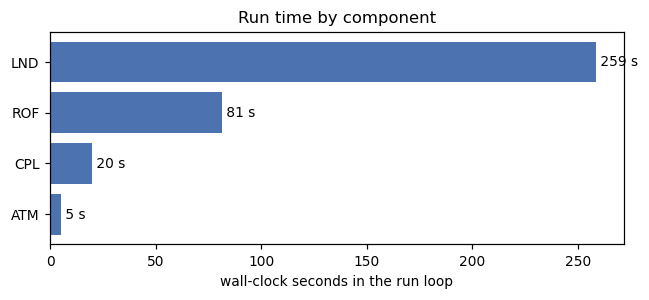

In [7]:
timing_files = sorted((CASE_DIR / "timing").glob("cesm_timing.*"), key=os.path.getmtime)
assert timing_files, "no cesm_timing file in the case timing/ directory"
timing_txt = timing_files[-1].read_text()
print("using", timing_files[-1].name, "\n")

hdr = re.search(r"---------------- TIMING PROFILE.*?Final Time\s*:\s*[\d.]+ seconds", timing_txt, re.S).group(0)
print("\n".join(l for l in hdr.splitlines() if re.search(r"Case|Machine|grid|compset|total pes|Cost|Throughput|Init Time|Run Time|Final Time", l)))

comp_t = dict(re.findall(r"^\s*(\w+) Run Time:\s+([\d.]+) seconds", timing_txt, re.M))
comp_t = {k: float(v) for k, v in comp_t.items() if k not in ("TOT",) and float(v) > 0}
fig, ax = plt.subplots(figsize=(6, 2.8))
names, vals = zip(*sorted(comp_t.items(), key=lambda kv: -kv[1]))
ax.barh(names, vals, color="#4c72b0")
for n, v in zip(names, vals):
    ax.text(v, n, f" {v:.0f} s", va="center")
ax.invert_yaxis(); ax.set_xlabel("wall-clock seconds in the run loop"); ax.set_title("Run time by component")
plt.tight_layout(); plt.show()

`LND` is CTSM, `ROF` is WRF-Hydro, `CPL` is the mediator's own work (remapping,
merging), `CPL COMM` is time spent waiting on data exchange. With everything on one
task there is no load imbalance to speak of; the split simply says how expensive each
model is per call — and CTSM was called 120 times.

`ESMF_Profile.summary` goes one level deeper: the tree of timed regions inside each
component. The top of it is the driver loop; below that CTSM's internal timers name
the physics (`canflux` is the canopy energy balance, `soiltemperature` the soil heat
equation, `hydro_without_drainage` the soil water column, `hbuf` history buffers).

In [8]:
prof = (RUN_DIR / "ESMF_Profile.summary").read_text().splitlines()
# lines look like: <indent>[COMP] phase  PETs PEs Count Mean Min MinPET Max MaxPET
rows = []
for line in prof[1:]:
    m = re.match(r"^(\s*)(\S.*?)\s{2,}(\d+)\s+(\d+)\s+(\d+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)\s+([\d.]+)\s+(\d+)\s*$", line)
    if m:
        depth = len(m.group(1)) // 2
        rows.append((depth, m.group(2).strip(), int(m.group(5)), float(m.group(6))))
prof_df = pd.DataFrame(rows, columns=["depth", "region", "count", "seconds"])
top = prof_df[prof_df.depth <= 4].copy()
top["region"] = ["  " * d + r for d, r in zip(top.depth, top.region)]
display(top.head(25).style.hide(axis="index").format({"seconds": "{:.2f}"}))

depth,region,count,seconds
1,[ESMF],1,462.51
2,[ensemble] RunPhase1,1,372.21
3,[ESM0001] RunPhase1,1,372.21
4,[LND] RunPhase1,120,258.66
4,[ROF] RunPhase1,120,81.40
4,[MED] med_phases_post_atm,120,9.57
4,[MED] med_phases_prep_rof,120,5.92
4,[ATM] RunPhase1,120,4.93
4,[MED] med_phases_prep_lnd,120,2.73
4,[LND-TO-MED] RunPhase1,120,2.39


## 4. The domain and its three grids

WRF-Hydro works on two grids of its own, and CTSM on a third:

| Grid | Spacing | Size | File | Used for |
|---|---|---|---|---|
| CTSM / DATM | 0.125° (~11 km) | 464 × 224, CONUS | `0.125nldas2_ESMFmesh_*.nc` | land model, forcing |
| WRF-Hydro **LSM grid** | 1 km | 234 × 319 | `DOMAIN/geo_em.d01.nc` | the grid on which WRF-Hydro *receives* CTSM's fields; also called the "coarse" or "geogrid" grid |
| WRF-Hydro **routing grid** | `DXRT` | LSM × `AGGFACTRT` | `DOMAIN/Fulldom_hires.nc` | terrain, channel and groundwater routing |

`geo_em.d01.nc` is a WRF geogrid file: a Lambert conformal projection centred on
41.5°N, 111.5°W. `HGT_M` is terrain height, `LANDMASK` land/water. The Great Salt Lake
should be obvious.

LSM grid: 234 x 319 cells, DX = 1000 m, centre 41.506N -111.504E
lat 40.07..42.94   lon -112.93..-110.07


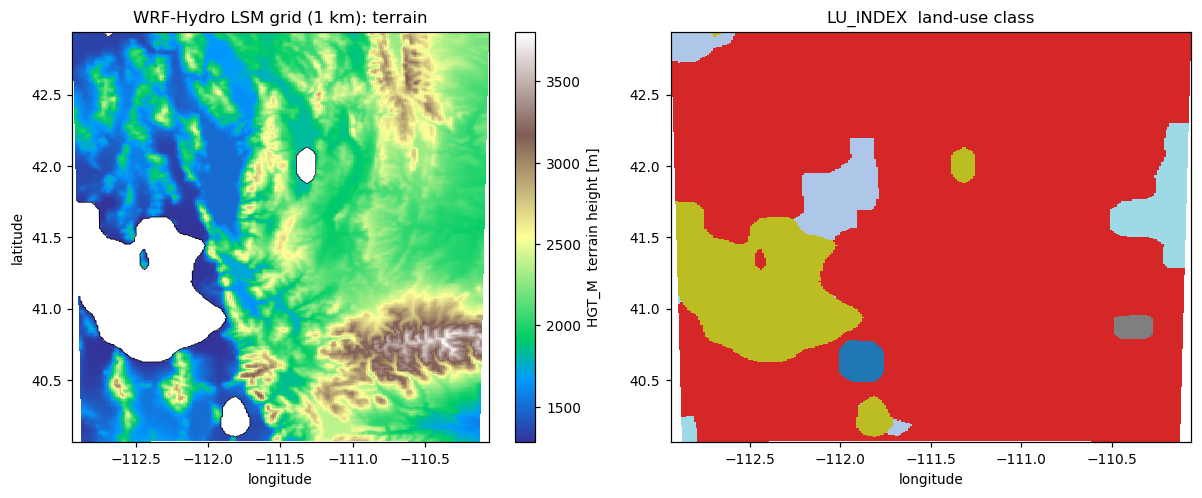

In [9]:
geo = xr.open_dataset(RUN_DIR / "DOMAIN" / "geo_em.d01.nc")
ny_lsm, nx_lsm = geo.sizes["south_north"], geo.sizes["west_east"]
print(f"LSM grid: {nx_lsm} x {ny_lsm} cells, DX = {geo.attrs['DX']:.0f} m, centre {geo.attrs['CEN_LAT']:.3f}N {geo.attrs['CEN_LON']:.3f}E")
print(f"lat {float(geo.XLAT_M.min()):.2f}..{float(geo.XLAT_M.max()):.2f}   lon {float(geo.XLONG_M.min()):.2f}..{float(geo.XLONG_M.max()):.2f}")

hgt = geo.HGT_M.isel(Time=0); lm = geo.LANDMASK.isel(Time=0)
# Every 1 km field in this notebook is drawn on these. geo_em stores row 0 at the NORTH
# edge, and the mediator's rof arrays use the same index order, so lat/lon from geo_em
# is the one georeference that is unambiguous (see the note after 4.1).
LON1K = geo.XLONG_M.isel(Time=0).values
LAT1K = geo.XLAT_M.isel(Time=0).values
ASPECT = 1 / np.cos(np.deg2rad(float(geo.attrs["CEN_LAT"])))   # so 1 km looks like 1 km on lat/lon axes
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
im = axs[0].pcolormesh(geo.XLONG_M.isel(Time=0), geo.XLAT_M.isel(Time=0), hgt.where(lm == 1), cmap="terrain", shading="auto")
axs[0].contour(geo.XLONG_M.isel(Time=0), geo.XLAT_M.isel(Time=0), lm, levels=[0.5], colors="k", linewidths=0.5)
plt.colorbar(im, ax=axs[0], label="HGT_M  terrain height [m]")
axs[0].set_title("WRF-Hydro LSM grid (1 km): terrain"); axs[0].set_xlabel("longitude"); axs[0].set_ylabel("latitude")
im = axs[1].pcolormesh(geo.XLONG_M.isel(Time=0), geo.XLAT_M.isel(Time=0), geo.LU_INDEX.isel(Time=0), cmap="tab20", shading="auto")
axs[1].set_title("LU_INDEX  land-use class"); axs[1].set_xlabel("longitude")
plt.tight_layout(); plt.show()

### 4.1 Does the routing grid match the namelist?

This check is cheap and it catches a class of error that produces *no* error message.
WRF-Hydro does not verify that `Fulldom_hires.nc` has the dimensions it expects; it
computes `ixrt = ix × AGGFACTRT`, `jxrt = jx × AGGFACTRT` from the LSM grid and reads
that many cells from the file, starting at the origin. If the file is bigger, the model
silently routes on a corner of it.

hydro.namelist : DXRT = 250 m, AGGFACTRT = 4  ->  expects routing grid 936 x 1276
Fulldom_hires  : 2340 x 3190 cells at 100 m spacing  (10x the LSM grid)

MISMATCH: WRF-Hydro read only the first 936 x 1276 cells (94 km x 128 km) of a 234 km x 319 km file.

channel cells in the block WRF-Hydro read  : 43485
channel cells in the whole Fulldom file     : 266324
reaches in CHRTOUT_DOMAIN1                  : 43485   <- equals the block count when the mismatch is real


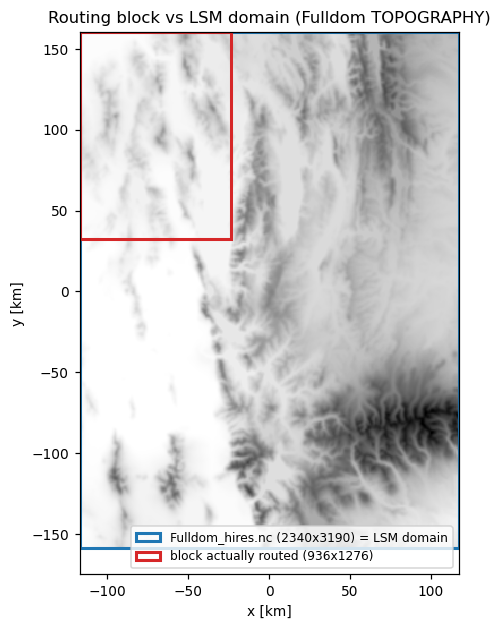

In [10]:
full = xr.open_dataset(RUN_DIR / "DOMAIN" / "Fulldom_hires.nc")
aggfact = int(float(HYDRO["AGGFACTRT"])); dxrt = float(HYDRO["DXRT"])
exp_ny, exp_nx = ny_lsm * aggfact, nx_lsm * aggfact
act_ny, act_nx = full.sizes["y"], full.sizes["x"]
file_dx = float(abs(full.x[1] - full.x[0]))

print(f"hydro.namelist : DXRT = {dxrt:.0f} m, AGGFACTRT = {aggfact}  ->  expects routing grid {exp_nx} x {exp_ny}")
print(f"Fulldom_hires  : {act_nx} x {act_ny} cells at {file_dx:.0f} m spacing  ({act_nx/nx_lsm:.0f}x the LSM grid)")
ok = (exp_ny, exp_nx) == (act_ny, act_nx)
print("\nMATCH" if ok else f"\nMISMATCH: WRF-Hydro read only the first {exp_nx} x {exp_ny} cells "
      f"({exp_nx*file_dx/1e3:.0f} km x {exp_ny*file_dx/1e3:.0f} km) of a {act_nx*file_dx/1e3:.0f} km x {act_ny*file_dx/1e3:.0f} km file.")

# Show it. Every channel cell in the block WRF-Hydro read must appear in CHRTOUT_DOMAIN1.
chg = full.CHANNELGRID
n_block = int((chg.isel(y=slice(0, exp_ny), x=slice(0, exp_nx)) >= 0).sum())
n_total = int((chg >= 0).sum())
chrt_files = sorted(RUN_DIR.glob("*.CHRTOUT_DOMAIN1"))
n_feat = xr.open_dataset(chrt_files[-1], decode_times=False).sizes["feature_id"]
print(f"\nchannel cells in the block WRF-Hydro read  : {n_block}")
print(f"channel cells in the whole Fulldom file     : {n_total}")
print(f"reaches in CHRTOUT_DOMAIN1                  : {n_feat}   <- equals the block count when the mismatch is real")

# Draw it in Fulldom's own coordinate frame, so the picture is right whichever way the
# file is stored: terrain from the file (thinned 10x), the block = rows 0:exp_ny, cols 0:exp_nx.
step = max(1, act_nx // 300)
xs, ys = full.x.values[::step] / 1e3, full.y.values[::step] / 1e3
topo = full.TOPOGRAPHY.values[::step, ::step]
fig, ax = plt.subplots(figsize=(5.2, 5.8))
ax.pcolormesh(xs, ys, topo, cmap="Greys", shading="auto")
xf, yf = full.x.values / 1e3, full.y.values / 1e3
ax.add_patch(plt.Rectangle((min(xf[0], xf[-1]), min(yf[0], yf[-1])), abs(xf[-1] - xf[0]), abs(yf[-1] - yf[0]), fill=False, ec="tab:blue", lw=2, label=f"Fulldom_hires.nc ({act_nx}x{act_ny}) = LSM domain"))
ax.add_patch(plt.Rectangle((min(xf[0], xf[exp_nx-1]), min(yf[0], yf[exp_ny-1])), abs(xf[exp_nx-1] - xf[0]), abs(yf[exp_ny-1] - yf[0]), fill=False, ec="tab:red", lw=2, label=f"block actually routed ({exp_nx}x{exp_ny})"))
ax.set_aspect("equal"); ax.set_xlabel("x [km]"); ax.set_ylabel("y [km]"); ax.legend(loc="lower right", fontsize=8)
ax.set_title("Routing block vs LSM domain (Fulldom TOPOGRAPHY)")
plt.tight_layout(); plt.show()
lsm_out = xr.open_dataset(sorted(RUN_DIR.glob("*.LSMOUT_DOMAIN1"))[-1], decode_times=False)

When the red box is smaller than the blue one, the routing physics are operating on the
wrong piece of ground: LSM cell (i, j) hands its runoff to routing cells
(4i…4i+3, 4j…4j+3), which in this file are 100 m cells sitting somewhere else entirely.
Streamflow still comes out — the channel network in the block is internally consistent
— but it is not the streamflow of the catchment under the LSM grid.

The fix is one or the other: regenerate `Fulldom_hires.nc` at 250 m, or set
`DXRT = 100` and `AGGFACTRT = 10` in `hydro.namelist` (with `DTRT_TER`/`DTRT_CH` reduced
to keep the routing stable at the finer spacing). Either way, re-run section 4.1 until
it says MATCH before trusting anything in section 8.

Three smaller things about georeferencing while we are here, because they bite:

- `Fulldom_hires.nc`'s `LATITUDE`/`LONGITUDE` arrays contain zeros in part of the domain
  and use 0–360 longitude. Do not georeference anything from them.
- `LSMOUT_DOMAIN1` stores its arrays north-up (row 0 = north, the same order as
  `geo_em`, `Fulldom` and the mediator), but its `y` coordinate variable runs
  south-to-north. Plot data against that `y` and the map is upside down. The
  `GeoTransform` attribute on `crs` is right.
- `CHRTOUT_GRID1` is the other way round: arrays south-up, matching its ascending `y`.
  Internally consistent, but flipped relative to `Fulldom`.
- `CHRTOUT_DOMAIN1`'s per-reach `latitude`/`longitude` are copied from `Fulldom`'s
  arrays, so they carry the same zeros and 0–360 values.
- The mediator's `rofExp_*`/`rofImp_*` arrays reshape to `(319, 234)` in `geo_em` index
  order — `rofExp_lat` equals `XLAT_M` exactly.

The rule this notebook follows: every 1 km field is drawn on `geo_em`'s `XLAT_M`/`XLONG_M`,
routing-grid fields on their own file's `x`/`y` only after checking that against the
terrain. When in doubt, plot terrain the same way and see whether the mountains are
where they should be — that is how the list above was established.

## 5. What CTSM sends to WRF-Hydro

This is the heart of the coupling. Each coupling step the mediator takes these fields
off CTSM's export state, regrids them from the 0.125° CONUS grid onto WRF-Hydro's 1 km
LSM grid, and puts them on WRF-Hydro's import state. The WRF-Hydro cap then copies
them into the model's `rt_domain` arrays.

| Mediator field name | WRF-Hydro array | Meaning | Units |
|---|---|---|---|
| `inst_soil_temperature{1..4}` | `stc` | soil temperature, 4 layers | K |
| `inst_total_soil_moisture_content{1..4}` | `smc` | total (liquid + ice) volumetric soil water | m³ m⁻³ |
| `inst_soil_moisture_content{1..4}` | `sh2ox` | liquid volumetric soil water | m³ m⁻³ |
| `Flrl_rofinfl_excess_sur` | `infxsrt` | infiltration-excess surface runoff, accumulated over the coupling interval | mm |
| `Flrl_rofsub` | `soldrain` | drainage out of the soil column | mm |

("`Flrl`" is CESM's prefix for a *flux* from *land* to *river*; "`inst_`" marks an
instantaneous state.) The four soil layers are the same in both models — bottoms at
0.10, 0.40, 1.00, 2.00 m — which is what the "flex-nsoil" work in this repository was
for. Section 9 verifies that from the restart file.

The names on the right are what appears in `LSMOUT_DOMAIN1`, which is exactly the
imported state as WRF-Hydro saw it. Comparing the `00:00` file (before any coupling) to
the `01:00` file (after 120 exchanges) shows the coupling happening.

In [11]:
def open_series(pattern):
    files = sorted(RUN_DIR.glob(pattern))
    if not files:
        return None
    # data_vars="all": per-file static variables (order, elevation, latitude ...) get a
    # time dimension too, so every variable can be selected with .isel(time=...).
    return xr.open_mfdataset(files, combine="nested", concat_dim="time", data_vars="all", decode_times=True)

lsm = open_series("*.LSMOUT_DOMAIN1")
print("LSMOUT times:", [str(t)[:16] for t in lsm.time.values])
rows = []
for v in ["stc", "smc", "sh2ox", "infxsrt", "sfcheadrt"]:
    for it, t in enumerate(lsm.time.values):
        da = lsm[v].isel(time=it)
        if "soil_layers" in da.dims:
            da = da.isel(soil_layers=0)
        rows.append((v, str(t)[:16], lsm[v].attrs.get("units", ""), float(da.min()), float(da.mean()), float(da.max())))
tab = pd.DataFrame(rows, columns=["field", "time", "units", "min", "mean", "max"])
display(tab.style.hide(axis="index").format({"min": "{:.4g}", "mean": "{:.4g}", "max": "{:.4g}"}))

LSMOUT times: ['2000-01-01T00:00', '2000-01-01T01:00']


field,time,units,min,mean,max
stc,2000-01-01T00:00,K,282,282,282
stc,2000-01-01T01:00,K,6.445e-12,6.632e-12,9.531e-12
smc,2000-01-01T00:00,fraction,0.25,0.25,0.25
smc,2000-01-01T01:00,fraction,2.175e-15,1.02e-14,1.432e-14
sh2ox,2000-01-01T00:00,fraction,0.25,0.25,0.25
sh2ox,2000-01-01T01:00,fraction,7.428e-16,3.532e-15,1.432e-14
infxsrt,2000-01-01T00:00,mm,0,0,0
infxsrt,2000-01-01T01:00,mm,0,0,0
sfcheadrt,2000-01-01T00:00,mm,0,0,0
sfcheadrt,2000-01-01T01:00,mm,0,0,0


At `00:00` every field is a constant: 282 K, 0.25 m³ m⁻³. Those are WRF-Hydro's
built-in placeholder initial values; nothing has been received yet.

At `01:00` the fields have spatial structure — so *something* arrived — but look at the
magnitudes. Soil temperature of order **10⁻¹² K** and soil moisture of order **10⁻¹⁴**
are not physical. Section 6 tracks down why. First, the maps:

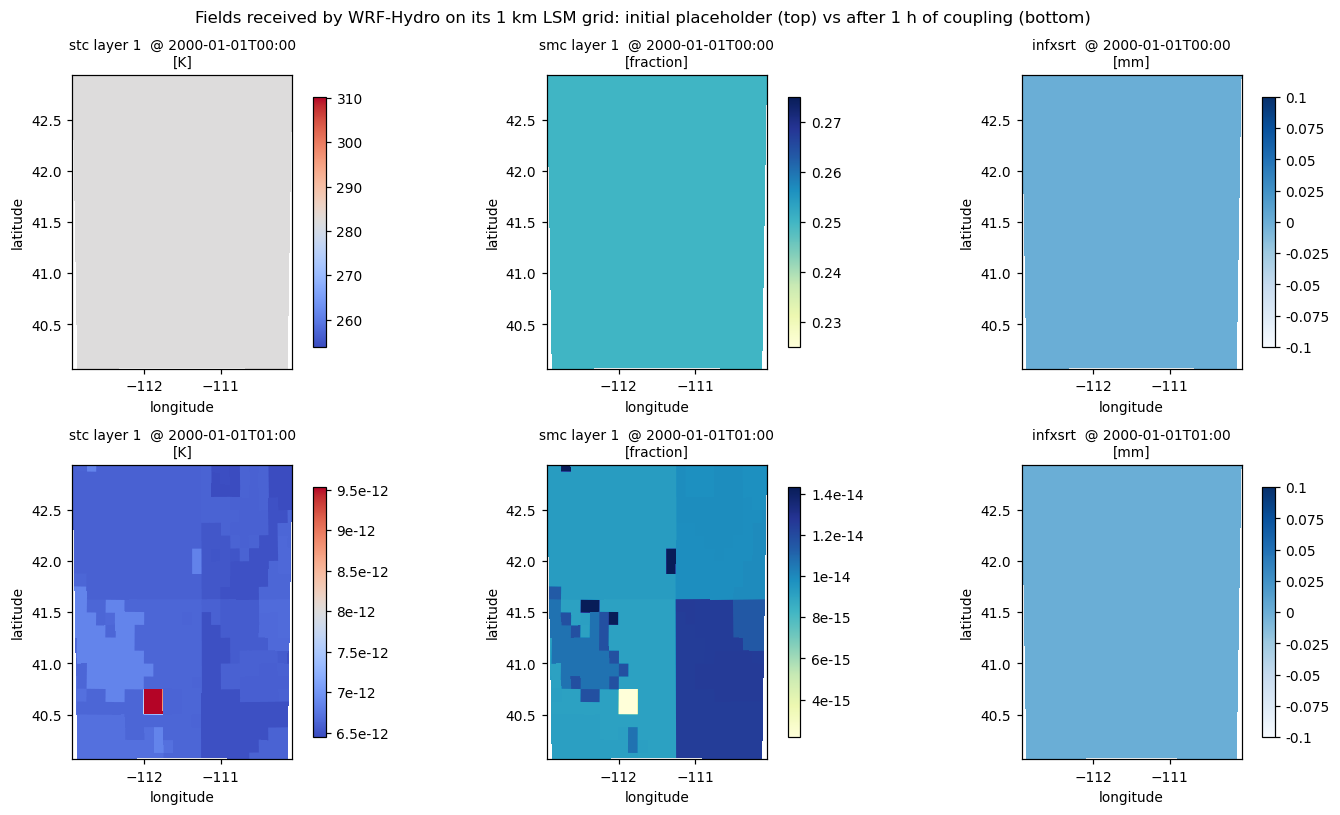

In [12]:
def lsm_map(ax, arr, title, **kw):
    # Draw a (319, 234) field of the 1 km LSM grid on geo_em's lat/lon.
    im = ax.pcolormesh(LON1K, LAT1K, np.asarray(arr), shading="auto", **kw)
    ax.set_aspect(ASPECT); ax.set_title(title, fontsize=9); ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    return im

fig, axs = plt.subplots(2, 3, figsize=(13, 7.5))
for r, it in enumerate([0, len(lsm.time) - 1]):
    t = str(lsm.time.values[it])[:16]
    for c, (v, cmap) in enumerate([("stc", "coolwarm"), ("smc", "YlGnBu"), ("infxsrt", "Blues")]):
        da = lsm[v].isel(time=it); label = v
        if "soil_layers" in da.dims:
            da = da.isel(soil_layers=0); label = f"{v} layer 1"
        im = lsm_map(axs[r, c], da, f"{label}  @ {t}\n[{lsm[v].attrs.get('units','')}]", cmap=cmap)
        plt.colorbar(im, ax=axs[r, c], shrink=0.85, format="%.3g")
plt.suptitle("Fields received by WRF-Hydro on its 1 km LSM grid: initial placeholder (top) vs after 1 h of coupling (bottom)")
plt.tight_layout(); plt.show()

The bottom row has the right *shape* — mountains cold, valleys warm, the lake missing —
and the wrong *scale*, by about fourteen orders of magnitude. `infxsrt` is exactly zero
everywhere: no surface runoff reached WRF-Hydro. In January over frozen ground with the
NLDAS forcing that is plausible on its own, but with the scaling problem it cannot be
read as a physical result either.

## 6. Following a field through the mediator

The mediator's restart file, `<case>.cpl.r.<date>.nc`, is the best debugging tool in
CESM and almost nobody opens it. It holds every field on every side of every exchange
at the final instant of the run:

| Variable prefix | What it is |
|---|---|
| `lndImp_*` | fields the mediator *imported from* the land: CTSM's export, on CTSM's grid |
| `rofExp_*` | fields the mediator *exported to* the river component: after regridding, on WRF-Hydro's grid |
| `rofImp_*` / `lndExp_*` | the reverse direction (section 7) |
| `lndFrac_*`, `rofFrac_*` | the fractions used to weight the regridding: `lfrac` is the land fraction of each cell as the mediator sees it |

So for soil temperature we can look at three things side by side: what CTSM produced,
what WRF-Hydro was given, and the weights in between.

In [13]:
cpl_files = sorted(RUN_DIR.glob("*.cpl.r.*.nc"))
assert cpl_files, "no mediator restart in the run directory"
cpl = xr.open_dataset(cpl_files[-1], decode_times=False)
print("mediator restart:", cpl_files[-1].name)

# --- CTSM side, CONUS grid ---------------------------------------------------
lnd_lon = cpl.lndFrac_lon.isel(time=0).values - 360.0
lnd_lat = cpl.lndFrac_lat.isel(time=0).values
lfrac   = cpl.lndFrac_lfrac.isel(time=0).values
# Work in numpy here: lndImp_*, lndFrac_* and rofExp_* carry *different* dimension
# names (lndImp_ny/nx vs lndFrac_ny/nx ...). An xarray .where() across them would
# broadcast to a 4-D 224x464x224x464 array and exhaust memory.
T1_lnd  = np.where(lfrac > 0, cpl.lndImp_inst_soil_temperature1.isel(time=0).values, np.nan)

# --- WRF-Hydro side, 1 km grid (stored flat, 74646 = 319 x 234) --------------
def rof2d(name):
    return cpl[name].isel(time=0).values.reshape(ny_lsm, nx_lsm)
T1_rof = rof2d("rofExp_inst_soil_temperature1")
lfrac_rof = rof2d("rofFrac_lfrac")

print(f"CTSM export  inst_soil_temperature1 over land : {np.nanmin(T1_lnd):.1f} .. {np.nanmax(T1_lnd):.1f} K")
print(f"WRF-Hydro import (after regrid)              : {T1_rof.min():.3g} .. {T1_rof.max():.3g} K")
print(f"land fraction on the CTSM grid  lndFrac_lfrac : {lfrac.min():.3g} .. {lfrac.max():.3g}")
print(f"land fraction on the WRF-Hydro grid rofFrac_lfrac : {lfrac_rof.min():.6g} .. {lfrac_rof.max():.6g}   (uniform)")

mediator restart: hydro-test-casper.cpl.r.2000-01-01-03600.nc
CTSM export  inst_soil_temperature1 over land : 254.4 .. 724.9 K
WRF-Hydro import (after regrid)              : 6.45e-12 .. 9.53e-12 K
land fraction on the CTSM grid  lndFrac_lfrac : 0 .. 1
land fraction on the WRF-Hydro grid rofFrac_lfrac : 2.45982e-14 .. 2.45982e-14   (uniform)


`rofFrac_lfrac` — the land fraction of each WRF-Hydro cell as the mediator computed it —
is **2.45982 × 10⁻¹⁴**, identically, in every cell. It should be 1 (or slightly less
over the lake). Every land→river field is regridded with a conservative method
(`mapconsf`) *weighted by this fraction*, so every field WRF-Hydro receives has been
multiplied by 2.46 × 10⁻¹⁴. That is the scale factor seen in section 5.

Where does that number come from? The WRF-Hydro cap tells ESMF the area of each of
its grid cells. In `wrfhydro_nuopc_gluecode.F90`, subroutine `add_area`:

```fortran
integer(ESMF_KIND_I4), PARAMETER :: R = 6376000 ! metres
...
gridarea(i,j) = radianarea(i,j) * R * R
```

ESMF computes areas on the unit sphere (steradians); the cap converts them to m² before
handing them back. Every other component's mesh leaves its areas in steradians. When
the mediator builds conservative weights *onto* the WRF-Hydro grid it normalises by the
destination area, and a destination area that is R² too large gives weights that are
1/R² too small:

In [14]:
R = 6376000.0
print(f"1 / R^2  with R = {R:.0f} m  =  {1/R**2:.6g}")
print(f"rofFrac_lfrac                =  {lfrac_rof.mean():.6g}")
print(f"ratio                        =  {lfrac_rof.mean() * R**2:.6f}")

1 / R^2  with R = 6376000 m  =  2.45982e-14
rofFrac_lfrac                =  2.45982e-14
ratio                        =  1.000000


Same number to six digits. Dividing the received field by `rofFrac_lfrac` recovers what
CTSM actually sent, which is the cleanest demonstration that the regridding itself is
fine and only the normalisation is wrong:

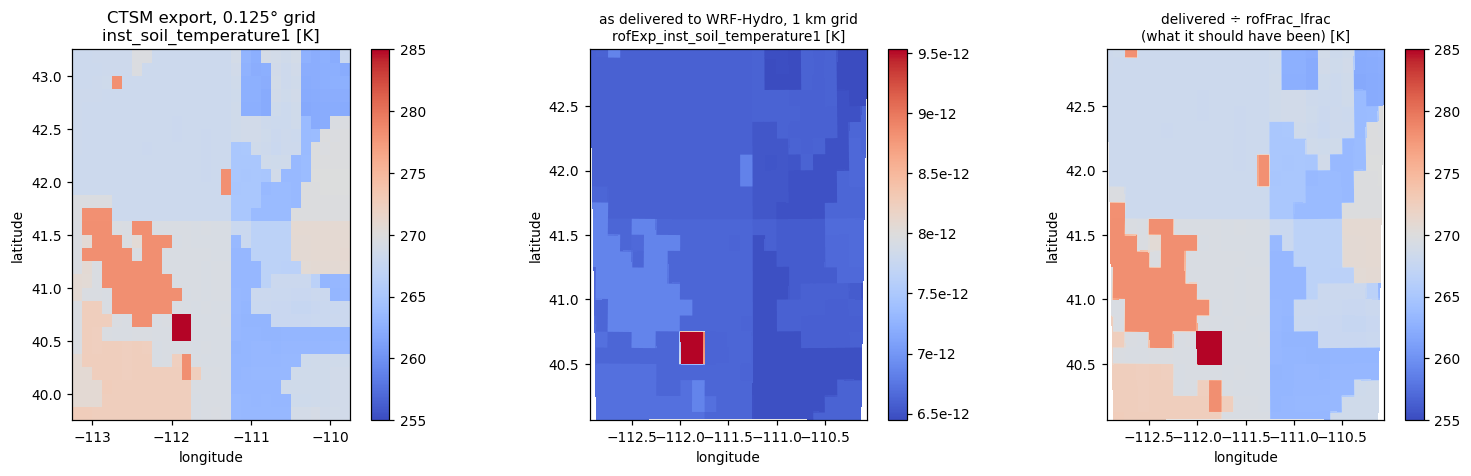

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4.4))
# CTSM side, zoomed to the WRF-Hydro window
win = (lnd_lon >= float(geo.XLONG_M.min()) - 0.3) & (lnd_lon <= float(geo.XLONG_M.max()) + 0.3) & \
      (lnd_lat >= float(geo.XLAT_M.min()) - 0.3)  & (lnd_lat <= float(geo.XLAT_M.max()) + 0.3)
jj, ii = np.where(win)
sl = (slice(jj.min(), jj.max() + 1), slice(ii.min(), ii.max() + 1))
im = axs[0].pcolormesh(lnd_lon[sl], lnd_lat[sl], T1_lnd[sl], cmap="coolwarm", vmin=255, vmax=285, shading="auto")
axs[0].set_title("CTSM export, 0.125° grid\ninst_soil_temperature1 [K]"); plt.colorbar(im, ax=axs[0])
axs[0].set_xlabel("longitude"); axs[0].set_ylabel("latitude")
im = lsm_map(axs[1], T1_rof, "as delivered to WRF-Hydro, 1 km grid\nrofExp_inst_soil_temperature1 [K]", cmap="coolwarm"); plt.colorbar(im, ax=axs[1], format="%.2g")
im = lsm_map(axs[2], T1_rof / lfrac_rof, "delivered ÷ rofFrac_lfrac\n(what it should have been) [K]", cmap="coolwarm", vmin=255, vmax=285); plt.colorbar(im, ax=axs[2])
axs[0].set_aspect(ASPECT)
plt.tight_layout(); plt.show()

The right-hand panel is the regridded CTSM soil temperature at the correct magnitude:
blocky, because 0.125° cells are ~11 km and the conservative map spreads each one over
~100 WRF-Hydro cells, and with the lake cells zero because CTSM has no land there.

**Fix:** remove the `R * R` scaling in `add_area` (or remove the `add_area` call and let
ESMF use its own areas). After that, `rofFrac_lfrac` should be ≈ 1 over land, and the
middle and right panels should be identical.

### 6.1 A second, smaller problem: cities

The left panel has a hot spot at Salt Lake City. Zoom out to the whole CTSM grid and
look for cells above 320 K — in January:

CTSM cells with layer-1 soil temperature > 320 K: 586   (max 725 K)


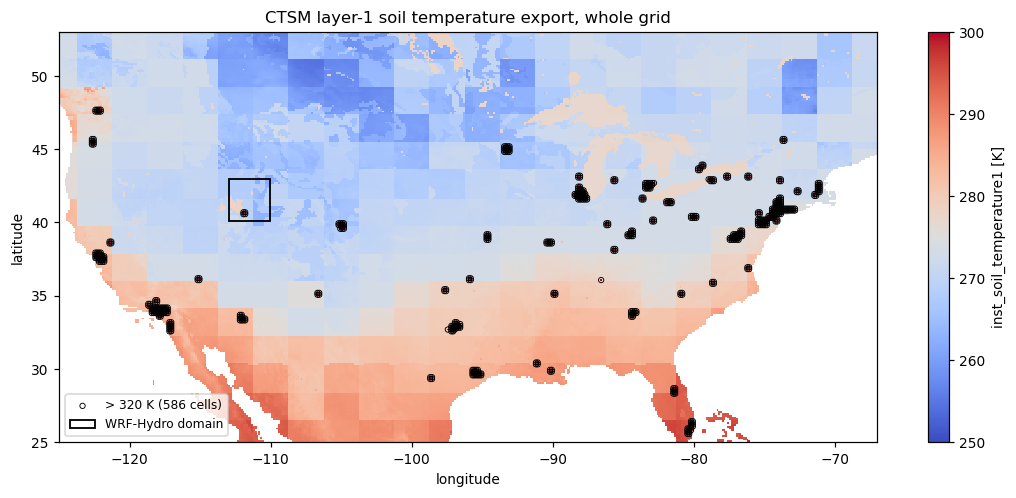


largest clusters of hot cells (rounded lat, lon) -> count:
lat   lon   
41.0  -74.0     44
42.0  -88.0     38
34.0  -118.0    36
40.0  -75.0     28
39.0  -77.0     28
33.0  -97.0     23
38.0  -122.0    20
26.0  -80.0     17
45.0  -93.0     16
40.0  -105.0    13
34.0  -84.0     12
33.0  -117.0    12


In [16]:
hot = np.isfinite(T1_lnd) & (T1_lnd > 320)
n_hot = int(hot.sum())
print(f"CTSM cells with layer-1 soil temperature > 320 K: {n_hot}   (max {np.nanmax(T1_lnd):.0f} K)")

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.pcolormesh(lnd_lon, lnd_lat, T1_lnd, cmap="coolwarm", vmin=250, vmax=300, shading="auto")
plt.colorbar(im, ax=ax, label="inst_soil_temperature1 [K]")
jj, ii = np.where(hot)
ax.scatter(lnd_lon[jj, ii], lnd_lat[jj, ii], s=12, facecolors="none", edgecolors="k", linewidths=0.6, label=f"> 320 K ({n_hot} cells)")
ax.add_patch(plt.Rectangle((float(geo.XLONG_M.min()), float(geo.XLAT_M.min())), float(geo.XLONG_M.max()-geo.XLONG_M.min()), float(geo.XLAT_M.max()-geo.XLAT_M.min()), fill=False, ec="k", lw=1.2, label="WRF-Hydro domain"))
ax.set_title("CTSM layer-1 soil temperature export, whole grid"); ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

# where are they?
cl = pd.DataFrame({"lat": np.round(lnd_lat[jj, ii]), "lon": np.round(lnd_lon[jj, ii])}).value_counts().head(12)
print("\nlargest clusters of hot cells (rounded lat, lon) -> count:")
print(cl.to_string())

Those clusters are New York, Chicago, Los Angeles, Washington, Philadelphia, Dallas,
the Bay Area, Miami, Minneapolis, Denver, Houston — and Salt Lake City. The anomaly is
confined to **urban** grid cells.

The cause is in how the export averages CTSM's sub-grid columns up to the grid cell.
`export_soil_temperature` in `src/cpl/nuopc/lnd_import_export.F90` calls

```fortran
call c2g(bounds, wrfhydro_nsoil, t_soisno_col, soil_temperature_grc, &
         c2l_scale_type='urbanf', l2g_scale_type='unity')
```

`urbanf` is the *flux* scaling for urban columns: it multiplies road columns by 3 and
wall columns by 3·(canyon height/width) so that per-unit-wall-area fluxes sum to a
per-unit-plan-area flux. Applied to a *temperature* it simply inflates the answer by
~1.4× wherever the urban landunit dominates. The state variant is `urbans`, which
normalises those factors away. Section 9 reproduces the correct number from the restart
file for the Salt Lake City cell, to show that the model state itself is fine.

(`export_liquid_soil_moisture` uses the same `urbanf` call and shows the same
symptom — `inst_soil_moisture_content1` reaches 0.92 m³ m⁻³, above any porosity.
CTSM's own `lnd2atmMod` does the same for `h2osoi_vol_grc`, so the pattern was copied
from upstream; it is still wrong for a state.)

## 7. What WRF-Hydro sends back

The return path carries two fields, both from the channel network, regridded from the
1 km grid back onto CTSM's cells:

| WRF-Hydro | Mediator field | Meaning |
|---|---|---|
| `sfchead` (surface water head) | `Flrr_flood` | water that the channel cannot hold, returned to the land surface |
| `volrmch` (main-channel volume) | `Flrr_volrmch` | water stored in the channel within the cell |

In CTSM these feed the flooding and channel-storage terms (`Flrr` = flux, river → land).
The `lndExp_*` copies are on the CTSM grid; note that outside the WRF-Hydro domain the
mediator has nothing to map from and leaves the CESM fill value 9.99 × 10²⁰ — mask it.

rofImp_Flrr_volrmch on 1 km grid : 0 .. 0.01563   nonzero cells 11282
rofImp_Flrr_flood   on 1 km grid : 0 .. 0
lndExp_Flrr_volrmch on CTSM grid : 0 .. 0.01557  (finite land cells: 51277)


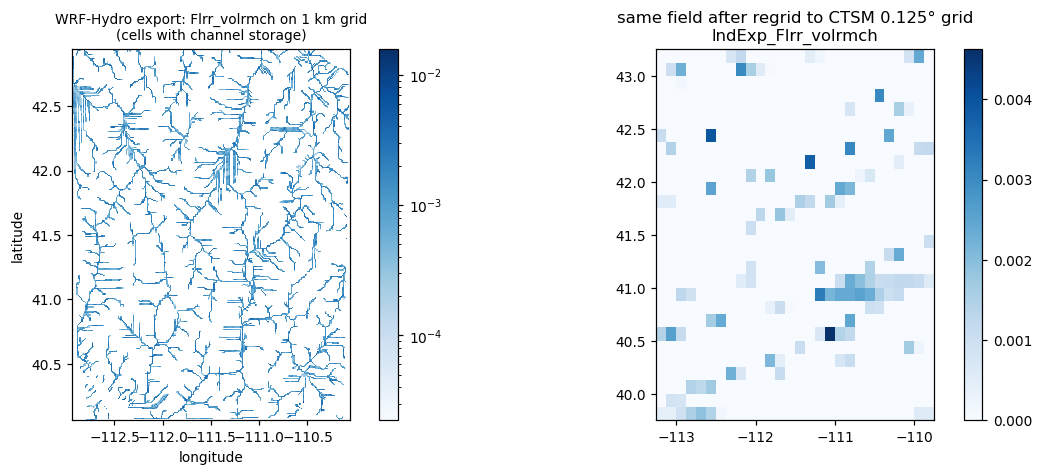

In [17]:
fill = 1e20
volr_rof = rof2d("rofImp_Flrr_volrmch")
flood_rof = rof2d("rofImp_Flrr_flood")
_v = cpl.lndExp_Flrr_volrmch.isel(time=0).values
volr_lnd = np.where((_v < fill) & (lfrac > 0), _v, np.nan)
print(f"rofImp_Flrr_volrmch on 1 km grid : {volr_rof.min():.4g} .. {volr_rof.max():.4g}   nonzero cells {int((volr_rof > 0).sum())}")
print(f"rofImp_Flrr_flood   on 1 km grid : {flood_rof.min():.4g} .. {flood_rof.max():.4g}")
print(f"lndExp_Flrr_volrmch on CTSM grid : {np.nanmin(volr_lnd):.4g} .. {np.nanmax(volr_lnd):.4g}  (finite land cells: {int(np.isfinite(volr_lnd).sum())})")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
im = lsm_map(axs[0], np.where(volr_rof > 0, volr_rof, np.nan), "WRF-Hydro export: Flrr_volrmch on 1 km grid\n(cells with channel storage)", cmap="Blues", norm=LogNorm()); plt.colorbar(im, ax=axs[0])
im = axs[1].pcolormesh(lnd_lon[sl], lnd_lat[sl], volr_lnd[sl], cmap="Blues", shading="auto")
axs[1].set_title("same field after regrid to CTSM 0.125° grid\nlndExp_Flrr_volrmch"); plt.colorbar(im, ax=axs[1]); axs[1].set_aspect(ASPECT)
plt.tight_layout(); plt.show()

Compare the left panel with the streamflow map in section 8: channel storage is where
the channels are, so the return field draws the river network on the 1 km grid, and the
regrid to 0.125° smears each cell's storage across its ~11 km parent. `Flrr_flood` is
zero — nothing overtopped in the first hour.

Because the direction is river → land, the destination is CTSM's mesh with correct
areas, so this path does **not** suffer the 1/R² problem. The magnitudes on the right
are plausible.

## 8. Streamflow, groundwater and lakes

WRF-Hydro's routing output. With the caveats from section 4.1 (the channel network is
the north-west block of the 100 m file) and section 5 (no surface runoff arrived), this
is a picture of the routing scheme running from its own initial state: groundwater
buckets that start 10 mm full leak into channels and the channels move that water
downstream.

**`CHRTOUT_DOMAIN1`** — one record per channel cell ("reach", `feature_id`):

| Variable | Meaning |
|---|---|
| `streamflow` | discharge leaving the reach [m³ s⁻¹] |
| `q_lateral` | water entering the reach from the side this step — overland flow, subsurface flow and groundwater-bucket outflow, summed [m³ s⁻¹] |
| `velocity` | flow velocity [m s⁻¹] |
| `order` | Strahler stream order: 1 for headwaters, increasing at confluences |
| `elevation` | channel bed elevation [m] |

**`CHRTOUT_GRID1`** — the same streamflow written back onto the routing grid, with an
`index` array that says which reach each grid cell is. That is what to plot here,
because this case's per-reach `latitude`/`longitude` are unusable (section 4.1).

times: ['2000-01-01T00:00', '2000-01-01T01:00']
reaches: 43485   streamflow at 2000-01-01T01:00: max 5.01 m3/s, median 0.177, reaches with flow > 0: 43390


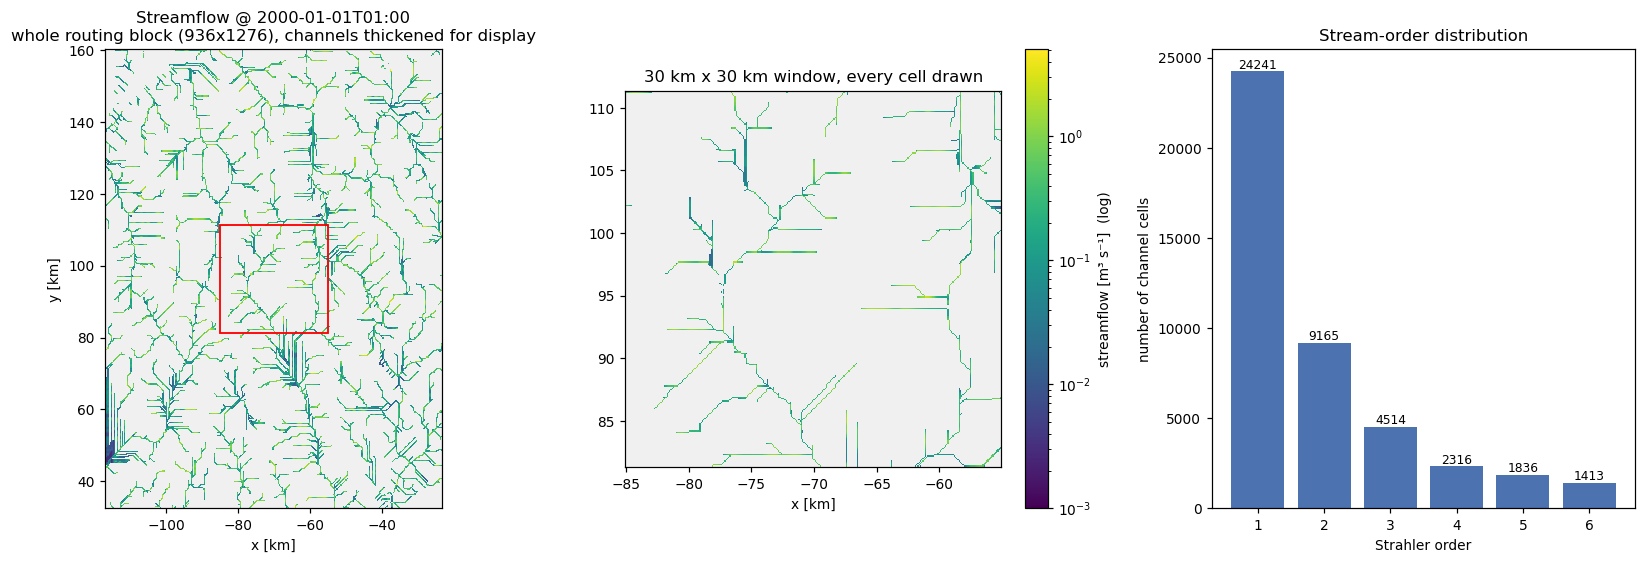

channel network: 85 connected pieces; the largest has 16604 of 43485 channel cells


In [18]:
chrt = open_series("*.CHRTOUT_DOMAIN1")
t_last = -1
q = chrt.streamflow.isel(time=t_last).compute()
print("times:", [str(t)[:16] for t in chrt.time.values])
print(f"reaches: {chrt.sizes['feature_id']}   streamflow at {str(chrt.time.values[t_last])[:16]}: "
      f"max {float(q.max()):.2f} m3/s, median {float(q.median()):.3g}, reaches with flow > 0: {int((q > 0).sum())}")

from scipy import ndimage

order = chrt.order.isel(time=t_last).compute()
cgrid = xr.open_dataset(sorted(RUN_DIR.glob("*.CHRTOUT_GRID1"))[-1], decode_times=False)
sf = cgrid.streamflow.isel(time=0).values
norm = LogNorm(vmin=1e-3, vmax=float(np.nanmax(sf)))

fig, axs = plt.subplots(1, 3, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.0, 1.0, 0.9]})
# Channels are one cell wide; drawn at screen resolution most of them vanish. A 3x3
# maximum filter thickens them for the overview only -- the values are unchanged.
sf_show = ndimage.maximum_filter(np.where(sf > 0, sf, 0), size=3)
im = axs[0].pcolormesh(cgrid.x / 1e3, cgrid.y / 1e3, np.where(sf_show > 0, sf_show, np.nan), cmap="viridis", norm=norm, shading="auto")
axs[0].set_aspect("equal"); axs[0].set_facecolor("#f0f0f0"); axs[0].set_xlabel("x [km]"); axs[0].set_ylabel("y [km]")
axs[0].set_title(f"Streamflow @ {str(chrt.time.values[t_last])[:16]}\nwhole routing block ({sf.shape[1]}x{sf.shape[0]}), channels thickened for display")

# a 30 km x 30 km window at full resolution
j0, i0, n = sf.shape[0] // 2 - 150, sf.shape[1] // 2 - 150, 300
win = (slice(j0, j0 + n), slice(i0, i0 + n))
im = axs[1].pcolormesh(cgrid.x[win[1]] / 1e3, cgrid.y[win[0]] / 1e3, np.where(sf[win] > 0, sf[win], np.nan), cmap="viridis", norm=norm, shading="auto")
axs[1].set_aspect("equal"); axs[1].set_facecolor("#f0f0f0"); axs[1].set_xlabel("x [km]")
axs[1].set_title("30 km x 30 km window, every cell drawn")
axs[0].add_patch(plt.Rectangle((float(cgrid.x[i0]) / 1e3, float(cgrid.y[j0]) / 1e3), n * file_dx / 1e3, n * file_dx / 1e3, fill=False, ec="r", lw=1.2))
plt.colorbar(im, ax=axs[1], label="streamflow [m³ s⁻¹]  (log)")

oc = pd.Series(order.values).value_counts().sort_index()
axs[2].bar(oc.index, oc.values, color="#4c72b0")
axs[2].set_xlabel("Strahler order"); axs[2].set_ylabel("number of channel cells"); axs[2].set_title("Stream-order distribution")
for k, v in oc.items():
    axs[2].text(k, v, str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

lab, ncomp = ndimage.label(cgrid["index"].values >= 0, structure=np.ones((3, 3)))
sizes = np.bincount(lab.ravel())[1:]
print(f"channel network: {ncomp} connected pieces; the largest has {sizes.max()} of {int((cgrid['index'].values >= 0).sum())} channel cells")

Headwater cells (order 1) dominate the count, as they must; the few high-order cells
are the main stems. The middle panel shows what the network actually looks like: a
proper dendritic tree, one cell wide, with flow increasing downstream. The overview on
the left is the same data with channels thickened so they survive being drawn at a few
hundred pixels — without that, most of a one-cell-wide network disappears and the map
looks like disconnected fragments, which is a display artefact, not a model problem.
The connected-component count printed underneath is the real test of connectivity.

The x/y come from `CHRTOUT_GRID1` itself and cover the block from section 4.1 — this
is where WRF-Hydro *thinks* the channels are given the grid it read.

### 8.1 Where does the water come from?

`q_lateral` is the total lateral inflow. Without surface runoff from CTSM, it should be
almost entirely groundwater-bucket outflow. `GWOUT_DOMAIN1` holds the buckets: one per
basin, with `depth` (bucket level, mm), `inflow` from soil drainage, and `outflow` to the
channel.

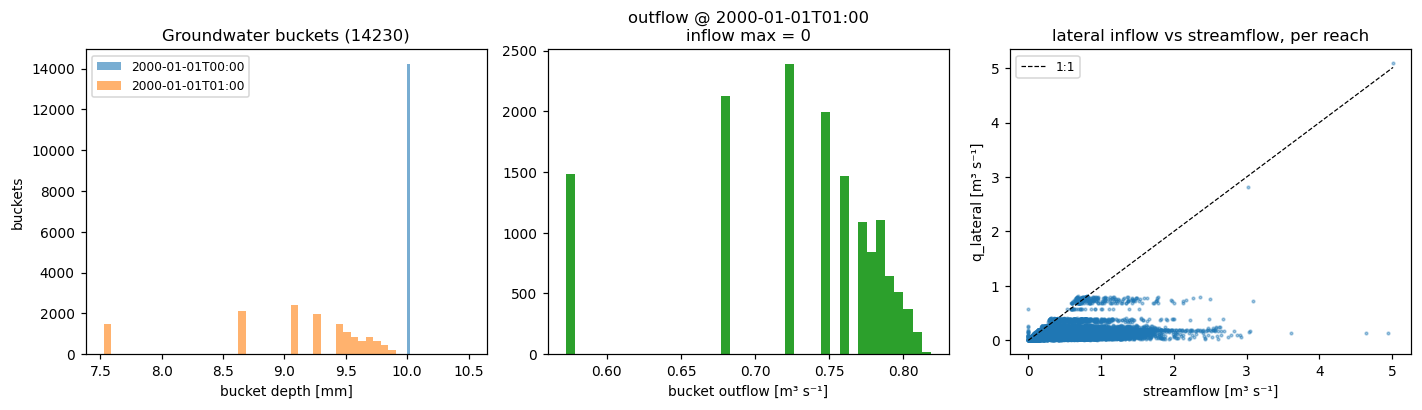

total bucket outflow 10382.46 m3/s   total q_lateral 3669.64 m3/s   total streamflow 13234.09 m3/s


In [19]:
gw = open_series("*.GWOUT_DOMAIN1")
fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
d0, d1 = gw.depth.isel(time=0).values, gw.depth.isel(time=-1).values
axs[0].hist(d0, bins=40, alpha=0.6, label=str(gw.time.values[0])[:16]); axs[0].hist(d1, bins=40, alpha=0.6, label=str(gw.time.values[-1])[:16])
axs[0].set_xlabel("bucket depth [mm]"); axs[0].set_ylabel("buckets"); axs[0].legend(fontsize=8); axs[0].set_title(f"Groundwater buckets ({gw.sizes['feature_id']})")
out = gw.outflow.isel(time=-1).values; inn = gw.inflow.isel(time=-1).values
axs[1].hist(out[out > 0], bins=40, color="tab:green"); axs[1].set_xlabel("bucket outflow [m³ s⁻¹]"); axs[1].set_title(f"outflow @ {str(gw.time.values[-1])[:16]}\ninflow max = {np.nanmax(inn):.3g}")
ql = chrt.q_lateral.isel(time=-1).values
axs[2].scatter(q.values, ql, s=3, alpha=0.4); axs[2].plot([0, q.max()], [0, q.max()], "k--", lw=0.8, label="1:1")
axs[2].set_xlabel("streamflow [m³ s⁻¹]"); axs[2].set_ylabel("q_lateral [m³ s⁻¹]"); axs[2].set_title("lateral inflow vs streamflow, per reach"); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"total bucket outflow {np.nansum(out):.2f} m3/s   total q_lateral {np.nansum(ql):.2f} m3/s   total streamflow {float(q.sum()):.2f} m3/s")

Bucket depths drop from a uniform 10 mm as the buckets drain; inflow is zero because
CTSM's drainage (`Flrl_rofsub`) arrived as zero. Reaches sit near the 1:1 line because
in the first hour almost all streamflow *is* local lateral inflow — water has not had
time to travel. In a longer run the points move below the line as routed flow from
upstream accumulates.

The three totals printed under the figure do not close, and should not be expected to
until section 4.1 says MATCH: the bucket set comes from `GWBUCKPARM.nc`/`GWBASINS.nc`
for the *whole* 100 m domain, but only the channel cells inside the block WRF-Hydro read
exist to receive their outflow. Water leaving a bucket whose basin has no channel cells
in the block simply disappears.

### 8.2 Lakes

`LAKEOUT_DOMAIN1`: level-pool reservoirs, one row each, with inflow, outflow and water
surface elevation.

30 lakes; showing the 10 with the largest inflow at 2000-01-01T01:00


lake_id,lat,lon,inflow,outflow,wse_m
30,42.870,-112.794,7.532,0.219,1350.3
6,41.803,-111.962,4.317,2.816,1510.2
27,42.898,-111.967,1.474,5.090,1682.9
7,42.357,-112.446,0.531,0.330,1602.1
2,41.619,-111.859,0.000,0.000,1496.2
3,41.988,-110.664,0.000,0.000,2236.5
5,42.294,-111.729,0.000,0.000,1634.1
8,41.582,-112.288,0.000,0.000,1288.3
9,41.579,-112.318,0.000,0.000,1288.4
10,41.383,-111.132,0.000,0.000,1965.9


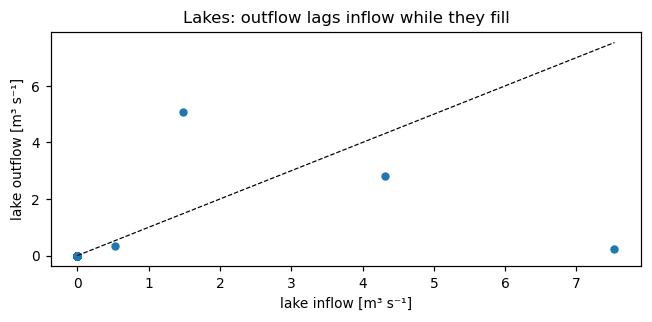

In [20]:
lk = open_series("*.LAKEOUT_DOMAIN1")
lk1 = lk.isel(time=-1)
df = pd.DataFrame({"lake_id": lk1.feature_id.values, "lat": lk1.latitude.values, "lon": lk1.longitude.values,
                   "inflow": lk1.inflow.values, "outflow": lk1.outflow.values, "wse_m": lk1.water_sfc_elev.values}).sort_values("inflow", ascending=False)
print(f"{lk.sizes['feature_id']} lakes; showing the 10 with the largest inflow at {str(lk.time.values[-1])[:16]}")
display(df.head(10).style.hide(axis="index").format({"lat": "{:.3f}", "lon": "{:.3f}", "inflow": "{:.3f}", "outflow": "{:.3f}", "wse_m": "{:.1f}"}))
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(df.inflow, df.outflow, s=20); ax.plot([0, df.inflow.max()], [0, df.inflow.max()], "k--", lw=0.8)
ax.set_xlabel("lake inflow [m³ s⁻¹]"); ax.set_ylabel("lake outflow [m³ s⁻¹]"); ax.set_title("Lakes: outflow lags inflow while they fill")
plt.tight_layout(); plt.show()

### 8.3 Time series

With two output times a "time series" is a line between two points, but the code is
the same for two hundred. `feature_id` values are stable across files, so pick reaches
by id — here the five with the highest final streamflow.

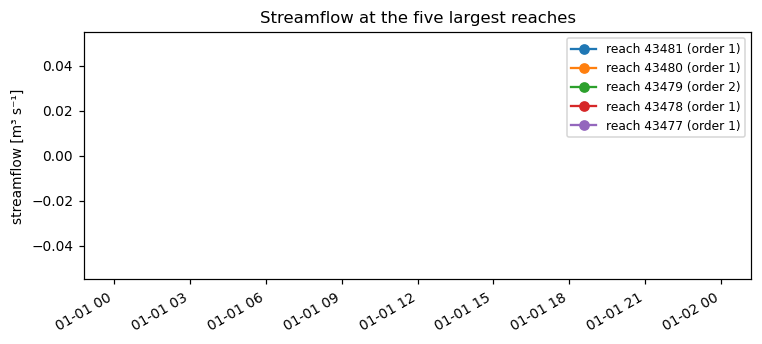

In [21]:
top_ids = q.sortby(q, ascending=False).feature_id.values[:5]
fig, ax = plt.subplots(figsize=(7, 3.2))
for fid in top_ids:
    ts = chrt.streamflow.sel(feature_id=fid)
    ax.plot(chrt.time.values, ts.values, marker="o", label=f"reach {int(fid)} (order {int(chrt.order.sel(feature_id=fid).isel(time=-1))})")
ax.set_ylabel("streamflow [m³ s⁻¹]"); ax.set_title("Streamflow at the five largest reaches"); ax.legend(fontsize=8)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 9. The land state, from CTSM's restart file

CTSM's restart file is not gridded. It stores the model's sub-grid hierarchy as flat
vectors:

```
gridcell  ─┬─ landunit (soil / crop / lake / wetland / glacier / urban) ─┬─ column ─┬─ patch (PFT)
           └─ ...                                                          └─ ...     └─ ...
```

Soil temperature and water live on **columns**. Each column carries its parent gridcell's
2-D index (`cols1d_ixy`, `cols1d_jxy`, 1-based), its landunit type (`cols1d_ityplun`)
and its weight in the gridcell (`cols1d_wtxy`). To put a column variable on the map you
weight-average the columns of each gridcell yourself. That is exactly what the coupler
export does — so doing it here, correctly, is the check on section 6.1.

`T_SOISNO` has 15 levels: 5 snow layers (top, zero when there is no snow) then the
ground layers. `DZSOI` gives the ground layer thicknesses.

In [22]:
rst_files = sorted(RUN_DIR.glob("*.clm2.r.*.nc"))
rst = xr.open_dataset(rst_files[-1], decode_times=False)
print("restart:", rst_files[-1].name, "  valid at", int(rst.timemgr_rst_curr_ymd), f"{int(rst.timemgr_rst_curr_tod)} s")
nlevsno = rst.sizes["levsno"]
dz = rst.DZSOI.isel(column=0).values
print("ground layer thickness DZSOI [m]:", dz[~np.isnan(dz)])
print("layer bottoms [m]:", np.cumsum(dz[~np.isnan(dz)]))
print("WRF-Hydro ZSOIL8 from hydro.namelist:", [HYDRO[f"ZSOIL8({i})"] for i in range(1, 5)])
LUNIT = {1: "soil", 2: "crop", 3: "landice", 4: "deep lake", 5: "wetland", 6: "urban TBD", 7: "urban HD", 8: "urban MD", 9: "urban MD"}

restart: hydro-test-casper.clm2.r.2000-01-01-03600.nc   valid at 20000101 3600 s
ground layer thickness DZSOI [m]: [0.1 0.3 0.6 1.  1. ]
layer bottoms [m]: [0.1 0.4 1.  2.  3. ]
WRF-Hydro ZSOIL8 from hydro.namelist: ['-0.10', '-0.40', '-1.00', '-2.00']


The first four CTSM ground layers end at 0.10, 0.40, 1.00, 2.00 m — the same as
WRF-Hydro's `ZSOIL8`. The fifth (2–3 m) is the bedrock layer added by this repository's
bedrock work; it is not exported.

Now grid layer-1 soil temperature two ways: weighted by `cols1d_wtxy` over *all active
columns* (what a state average should be), and restricted to soil columns only.

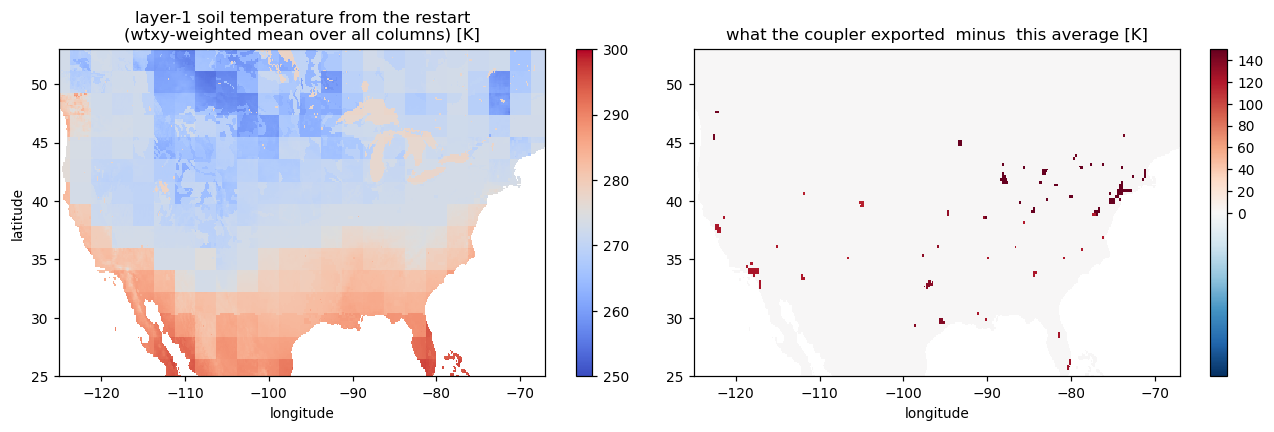

max |export - weighted average| over non-urban cells: 0.000 K


In [23]:
ny_c, nx_c = lnd_lat.shape
ixy = rst.cols1d_ixy.values.astype(int) - 1
jxy = rst.cols1d_jxy.values.astype(int) - 1
wt  = rst.cols1d_wtxy.values
act = rst.cols1d_active.values == 1
lun = rst.cols1d_ityplun.values.astype(int)
T1c = rst.T_SOISNO.isel(levtot=nlevsno).values         # first ground layer
ok  = act & (wt > 0) & np.isfinite(T1c) & (T1c > 0)

def grid_weighted(vals, mask):
    num = np.zeros((ny_c, nx_c)); den = np.zeros((ny_c, nx_c))
    np.add.at(num, (jxy[mask], ixy[mask]), vals[mask] * wt[mask])
    np.add.at(den, (jxy[mask], ixy[mask]), wt[mask])
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan)

T1_all  = grid_weighted(T1c, ok)
T1_soil = grid_weighted(T1c, ok & (lun == 1))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
im = axs[0].pcolormesh(lnd_lon, lnd_lat, T1_all, cmap="coolwarm", vmin=250, vmax=300, shading="auto")
axs[0].set_title("layer-1 soil temperature from the restart\n(wtxy-weighted mean over all columns) [K]"); plt.colorbar(im, ax=axs[0])
diff = T1_lnd - T1_all
im = axs[1].pcolormesh(lnd_lon, lnd_lat, diff, cmap="RdBu_r", norm=TwoSlopeNorm(0, -5, 150), shading="auto")
axs[1].set_title("what the coupler exported  minus  this average [K]"); plt.colorbar(im, ax=axs[1])
for a in axs: a.set_xlabel("longitude")
axs[0].set_ylabel("latitude")
plt.tight_layout(); plt.show()
print(f"max |export - weighted average| over non-urban cells: {np.nanmax(np.abs(diff[np.isfinite(T1_soil)])):.3f} K")

Zero everywhere except the cities, where the export is up to ~150 K warmer than the
properly weighted state. The state in the restart is physically fine; only the export
averaging is off. For the Salt Lake City cell explicitly:

In [24]:
slc_lat, slc_lon = 40.5625, -111.9375
j, i = np.unravel_index(np.argmin((lnd_lat - slc_lat) ** 2 + (lnd_lon - slc_lon) ** 2), lnd_lat.shape)
cols = np.where((jxy == j) & (ixy == i))[0]
ityp = rst.cols1d_ityp.values.astype(int)
COLTYPE = {71: "roof", 72: "sunlit wall", 73: "shaded wall", 74: "impervious road", 75: "pervious road", 1: "soil"}
rows = [(int(c), LUNIT.get(lun[c], lun[c]), COLTYPE.get(ityp[c], ityp[c]), wt[c], T1c[c]) for c in cols]
display(pd.DataFrame(rows, columns=["column", "landunit", "column type", "weight in gridcell", "T layer 1 [K]"]).style.hide(axis="index").format({"weight in gridcell": "{:.4f}", "T layer 1 [K]": "{:.1f}"}))
print(f"weighted mean over columns     : {np.nansum(wt[cols]*T1c[cols])/np.nansum(wt[cols]):.1f} K")
print(f"value the coupler exported     : {T1_lnd[j, i]:.1f} K")
print("urbanf scale factors: roof x1, walls x3(H/W), roads x3  -> weighted sum ~ 1.4x too large")

column,landunit,column type,weight in gridcell,T layer 1 [K]
41417,soil,soil,0.0000,269.5
41418,urban MD,roof,0.5500,272.4
41419,urban MD,sunlit wall,0.1500,271.5
41420,urban MD,shaded wall,0.1500,269.2
41421,urban MD,impervious road,0.0667,267.2
41422,urban MD,pervious road,0.0833,269.5


weighted mean over columns     : 271.2 K
value the coupler exported     : 387.4 K
urbanf scale factors: roof x1, walls x3(H/W), roads x3  -> weighted sum ~ 1.4x too large


## 10. The logs

Each component writes its own log; `case.st_archive` gzips them into
`archive/<case>/logs/`. The land and mediator logs are short and worth reading once —
they list every exported and imported field by name, which is how you confirm a new
coupling field is actually connected. `cesm.log` is the driver's combined stdout and
is large (WRF-Hydro is chatty); grep it rather than read it.

In [25]:
def latest_log(prefix):
    files = sorted((ARCHIVE / "logs").glob(f"{prefix}.log.*"), key=os.path.getmtime) if (ARCHIVE / "logs").is_dir() else []
    files += sorted(RUN_DIR.glob(f"{prefix}.log.*"), key=os.path.getmtime)
    return files[-1] if files else None

def read_log(p):
    return gzip.open(p, "rt", errors="replace").read() if p.suffix == ".gz" else p.read_text(errors="replace")

for comp in ["med", "lnd", "atm", "cesm"]:
    p = latest_log(comp)
    if p is None:
        print(f"--- {comp}.log: not found"); continue
    txt = read_log(p)
    n_lines = txt.count("\n")
    warn = [l for l in txt.splitlines() if re.search(r"warn|error|fail", l, re.I) and "ESMF_LogFoundError" not in l]
    print(f"--- {p.name}: {n_lines} lines, {len(warn)} lines mentioning warning/error/fail")
    for l in warn[:6]:
        print("     ", l.strip()[:140])

--- med.log.5845813.casper-pbs.260913-104517.gz: 641 lines, 0 lines mentioning warning/error/fail
--- lnd.log.5845813.casper-pbs.260913-104517.gz: 2272 lines, 243 lines mentioning warning/error/fail
--- atm.log.5845813.casper-pbs.260913-104517.gz: 366 lines, 0 lines mentioning warning/error/fail
--- cesm.log.5845813.casper-pbs.260913-104517.gz: 4430819 lines, 1 lines mentioning warning/error/fail


Two of those deserve a closer look.

**`cesm.log` is 4.4 million lines for a one-hour run.** Almost all of it is one debug
`write(*,*) 'layer, h2osoi_liq: '` in `src/biogeophys/SoilWaterMovementMod.F90` (1.5 M
lines) plus `INFILTRATION_DIAG` prints in the WRF-Hydro cap. They will make a
multi-day run unmanageable; remove or guard them before scaling up.

**CTSM reports a water-balance error every step.** `errh2o` is the mismatch between the
change in a column's water storage and the fluxes in and out, in mm. Values of order
10⁷ mm are not rounding: a column is in an impossible state. The warnings name the
column, and the restart file says where it is.

120 column water-balance warnings over 120 steps, 27 distinct columns; |errh2o| up to 1.18e+07 mm


global column,warnings,lat,lon,landunit,total soil liquid [kg m-2],aquifer WA [mm]
93343,85,51.812,-96.188,soil,0.0,5000
82982,4,49.562,-123.812,soil,0.0,5000
82413,3,49.438,-123.812,soil,0.0,5000
81839,2,49.312,-124.938,soil,0.0,5000
82411,2,49.438,-124.062,soil,0.0,5000
89188,2,50.938,-124.812,soil,0.0,5000
84704,2,49.938,-124.438,soil,0.0,5000
85284,1,50.062,-124.062,soil,0.0,5000


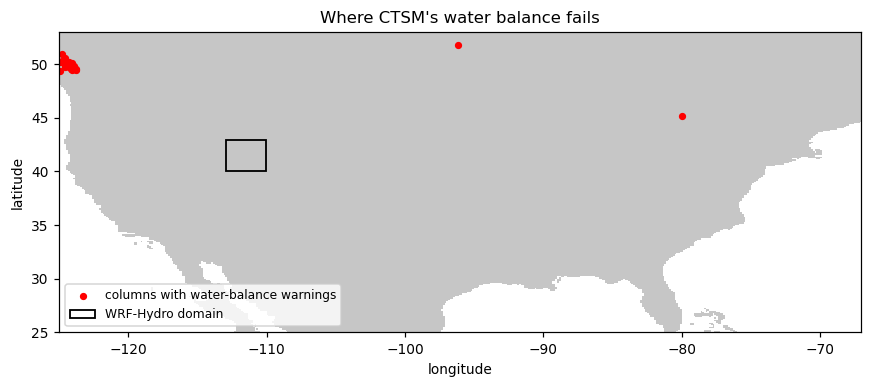

In [26]:
p = latest_log("lnd")
recs = re.findall(r"column-level water balance error\s+nstep=\s*(\d+)\s+local indexc=\s*(\d+)\s+global indexc=\s*(\d+)\s+errh2o=\s*([-\d.E+]+)", read_log(p)) if p else []
if recs:
    wb = pd.DataFrame(recs, columns=["nstep", "local_c", "global_c", "errh2o"]).astype({"nstep": int, "global_c": int, "errh2o": float})
    counts = wb.global_c.value_counts()
    print(f"{len(wb)} column water-balance warnings over {wb.nstep.nunique()} steps, {len(counts)} distinct columns; |errh2o| up to {wb.errh2o.abs().max():.3g} mm")
    rows = []
    for gc, n in counts.head(8).items():
        i = gc - 1                                      # global column index is 1-based
        rows.append((gc, n, float(rst.cols1d_lat[i]), float(rst.cols1d_lon[i]) - 360, LUNIT.get(lun[i], lun[i]),
                     float(np.nansum(rst.H2OSOI_LIQ.isel(column=i, levtot=slice(nlevsno, None)).values)), float(rst.WA[i])))
    display(pd.DataFrame(rows, columns=["global column", "warnings", "lat", "lon", "landunit", "total soil liquid [kg m-2]", "aquifer WA [mm]"])
            .style.hide(axis="index").format({"lat": "{:.3f}", "lon": "{:.3f}", "total soil liquid [kg m-2]": "{:.1f}", "aquifer WA [mm]": "{:.0f}"}))
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.pcolormesh(lnd_lon, lnd_lat, np.where(lfrac > 0, 1, np.nan), cmap="Greys", vmin=0, vmax=3, shading="auto")
    ax.scatter([float(rst.cols1d_lon[g-1]) - 360 for g in counts.index], [float(rst.cols1d_lat[g-1]) for g in counts.index], s=14, c="r", label="columns with water-balance warnings")
    ax.add_patch(plt.Rectangle((float(geo.XLONG_M.min()), float(geo.XLAT_M.min())), float(geo.XLONG_M.max()-geo.XLONG_M.min()), float(geo.XLAT_M.max()-geo.XLAT_M.min()), fill=False, ec="k", lw=1.2, label="WRF-Hydro domain"))
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.legend(loc="lower left", fontsize=8); ax.set_title("Where CTSM's water balance fails")
    plt.tight_layout(); plt.show()
else:
    print("no water-balance warnings in lnd.log")

The failing columns are soil columns at the northern edge of the NLDAS grid — most on
the coast of British Columbia, a couple more in Manitoba and Ontario — with **zero
liquid water in every soil layer**. They are outside the region the NLDAS-2 forcing
actually covers, and far outside the WRF-Hydro domain. They do not affect this
coupling, but they are a sign that the interpolated initial file plus the 4-layer soil
configuration leaves some columns in a state CTSM cannot balance. The land model keeps
running (the check is a warning, not an abort) and the cost is a line per step.

And the list of fields the mediator actually connected between land and river, taken
from `med.log` — the definitive answer to "is my field being exchanged?":

In [27]:
p = latest_log("med")
if p:
    txt = read_log(p)
    fields = sorted(set(re.findall(r"\b(Flrl_\w+|Flrr_\w+|inst_soil\w+|inst_total_soil\w+|Sl_soil\w+)\b", txt)))
    print("\n".join(fields) if fields else "(no lnd<->rof field names found in med.log)")

Flrl_irrig
Flrl_rofgwl
Flrl_rofh2osfc_sur
Flrl_rofh2osfc_thresh
Flrl_rofi
Flrl_rofinfl_excess_sur
Flrl_rofsat_excess_sur
Flrl_rofsub
Flrl_rofsur
Flrr_flood
Flrr_volr
Flrr_volrmch
Sl_soilliq
Sl_soilw
inst_soil_moisture_content
inst_soil_temperature
inst_total_soil_moisture_content


## 11. Summary

**What works.** The three components initialise, run a 30 s coupled loop for an hour,
exchange fields in both directions, write restarts, and shut down cleanly. WRF-Hydro's
routing (channels, groundwater buckets, lakes) runs from its initial state and produces
a coherent streamflow field. The river → land return path delivers channel storage to
CTSM at plausible magnitudes. CTSM's soil layering matches WRF-Hydro's.

**What does not, yet — in order of importance.**

1. **Every land → river field is scaled by 1/R² = 2.46 × 10⁻¹⁴** (section 6). WRF-Hydro
   receives soil temperature of ~10⁻¹² K. Cause: `add_area` in
   `wrfhydro_nuopc_gluecode.F90` hands ESMF cell areas in m² instead of steradians, so
   the conservative regrid weights onto the WRF-Hydro grid are normalised by an area
   R² too large. Fix: drop the `R * R` (or the whole `add_area` call). Until this is
   fixed nothing WRF-Hydro computes from land input is meaningful.
2. **The routing grid does not match the namelist** (section 4.1). `Fulldom_hires.nc` is
   100 m / 3190 × 2340; `hydro.namelist` says 250 m / `AGGFACTRT = 4`. WRF-Hydro routed on
   the north-west 1276 × 936 block of the file. Fix either side; re-run section 4.1
   until it says MATCH.
3. **Soil temperature and liquid soil moisture exports are inflated ~1.4× in urban
   cells** (sections 6.1, 9). `c2l_scale_type='urbanf'` (a flux scaling) is used for a
   state; use `'urbans'`. Affects every city in CONUS, including Salt Lake City inside
   the WRF-Hydro domain.
4. **No CTSM history output.** Not a bug — set `hist_nhtfrq = -1`, `hist_mfilt = 24` in
   `user_nl_clm` for hourly history so that the land side can be plotted directly rather
   than reconstructed from the restart.

**Also worth knowing.**
- The custom `nuopc.runseq` couples every 30 s, which makes CTSM the cost driver
  (259 s of the 372 s run loop). If that interval was not intended, the CIME defaults
  (`ATM_NCPL`/`LND_NCPL` = 48, `ROF_NCPL` = 24) give 30 min / 1 h.
- Debug `write` statements in `SoilWaterMovementMod.F90` and the WRF-Hydro cap put
  4.4 million lines in `cesm.log` for one simulated hour (section 10).
- CTSM logs a water-balance error every step from a handful of dry columns on the
  northern edge of the NLDAS grid, outside the WRF-Hydro domain (section 10).

**Re-running this notebook after a fix** needs no changes: it reads whatever the latest
run left in the run directory. The numbers to watch are `rofFrac_lfrac` (should become
≈ 1), the MATCH line in 4.1, and the hot-cell count in 6.1 (should become 0).